## Spring-Mass-Damper System (revisited)

**See first:** [Introduction to PINNs](./1_pinn.ipynb)

In this notebook we use a physics-informed neural network (PINN) to estimate the three parameters of a forced spring–mass–damper system simultaneously. We will work with the same system as in the [previous Python notebook](./1_pinn.ipynb), but here we will introduce some more advanced features; in particular:

- The dynamical system now has an input, which we need to choose
- Instead of describing $y(t)$ purely by a neural network, we will give it some structure to encode the (here known) initial conditions $y(0) = y_0$ and $v(0) = v_0$
- We perform validation a little more carefully 
- We enforce the positivity of the parameters $m$, $k$, and $b$
- We scale the loss function

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm

## Forced spring–mass–damper system

### System dynamics 
We consider the following spring-mass-damper
$$m\ddot y(t)+b\dot y(t)+ky(t)=F(t),\tag{1}$$

with *known* initial conditions $y(0)=0$ and $\dot y(0)=0$. The system is driven by an external force, $F(t)$. The unknown parameters are the mass $m$, damping coefficient $b$, and spring constant $k$, i.e., the vector of parameters to be estimated is $\theta = (m, k, b)$.

### Choice of excitation

The excitation $F(t) = 0$ is certainty not a good idea. If we have the ODE $m\ddot y(t)+b\dot y(t)+ky(t)=0$, then the parameters $\theta_1 = (m, b, k)$ and $\theta_2 = c\theta_1$, with $c>0$, produce identical outputs and the parameters are not identifiable. 

A common heuristic is to choose a signal with multiple frequencies, e.g., 
$$F(t)=100\sin(10t)+50\sin(25t).$$
There is a notion of *optimal choice* for the input signal: roughly speaking, an input is optimal if it helps extract maximum information out of the system, i.e., if the output, $y(t)$, is most informative. [Optimal experimental design](https://en.wikipedia.org/wiki/Optimal_experimental_design) studies exactly this question. Here we will proceed with this heuristic. You can later play with different choices of $F$ and see how they affect the quality of estimation.

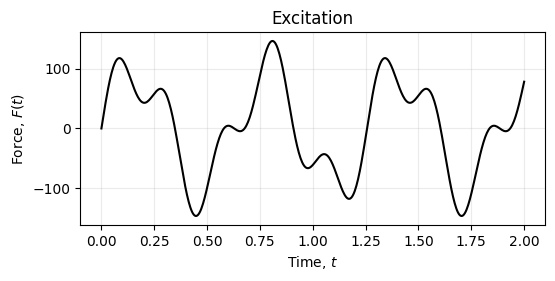

In [2]:
# True parameters and experimental settings
m_true, b_true, k_true = 1.0, 4.0, 250.0
y0, v0 = 0.0, 0.0
t_final = 2.0

def forcing(t):
    """External force signal"""
    return 100.0 * torch.sin(10*t) + 50.0 * torch.sin(25*t) 

t_force = torch.linspace(0.0, t_final, 500)
plt.figure(figsize=(6, 2.5))
plt.plot(t_force, forcing(t_force), color="black")
plt.xlabel("Time, $t$"); plt.ylabel("Force, $F(t)$")
plt.title("Excitation")
plt.grid(alpha=0.25)
plt.show()

## Synthetic observations

The following [fourth-order Runge–Kutta solver](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#Explicit_Runge%E2%80%93Kutta_methods) (RK4) generates a reference trajectory. In a real experiment this step would be replaced by measurements from the physical system; the PINN will receive only the noisy observations and the known force.

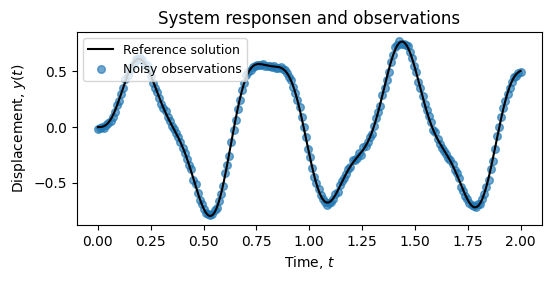

In [3]:
def state_derivative(t, state, m, b, k):
    y, velocity = state.unbind()
    acceleration = (forcing(t) - b * velocity - k * y) / m
    return torch.stack((velocity, acceleration))

@torch.no_grad()
def simulate_oscillator(t, m, b, k, y_initial=0.0, v_initial=0.0):
    """Simulate the forced oscillator at the supplied time points using RK4."""
    state = torch.tensor([y_initial, v_initial], dtype=t.dtype, device=t.device)
    displacements = [state[0]]

    for i in range(t.numel() - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        q1 = state_derivative(ti, state, m, b, k)
        q2 = state_derivative(ti + dt / 2, state + dt * q1 / 2, m, b, k)
        q3 = state_derivative(ti + dt / 2, state + dt * q2 / 2, m, b, k)
        q4 = state_derivative(ti + dt, state + dt * q3, m, b, k)
        state = state + dt * (q1 + 2 * q2 + 2 * q3 + q4) / 6
        displacements.append(state[0])

    return torch.stack(displacements).view(-1, 1)

torch.manual_seed(1)
t_test = torch.linspace(0.0, t_final, 1001).view(-1, 1)
y_exact = simulate_oscillator(t_test[:, 0], m_true, b_true, k_true, y0, v0)

n_observations = 200
noise_std = 0.01
observation_indices = torch.linspace(0, t_test.shape[0] - 1, n_observations).int()
t_obs = t_test[observation_indices]
y_obs = y_exact[observation_indices] + noise_std * torch.randn_like(t_obs)

plt.figure(figsize=(6, 2.5))
plt.plot(t_test[:, 0], y_exact[:, 0], color="k", label="Reference solution")
plt.scatter(t_obs[:, 0], y_obs[:, 0], s=30, alpha=0.65, color="tab:blue", label="Noisy observations")
plt.xlabel("Time, $t$")
plt.ylabel("Displacement, $y(t)$")
plt.title("System responsen and observations")
plt.legend(fontsize=9)
plt.show()

## Splitting into training and validation data

We reserve every fifth observation for validation. These points are not used in the loss, so they provide an independent check of the fitted trajectory at measured locations. The remaining observations and the physics residual are used for training.

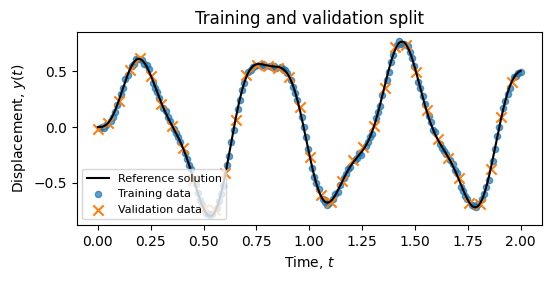

Training observations:   160
Validation observations: 40


In [4]:
observation_number = torch.arange(n_observations)
validation_mask = observation_number % 5 == 0
training_mask = ~validation_mask

t_train, y_train = t_obs[training_mask], y_obs[training_mask]
t_validation, y_validation = t_obs[validation_mask], y_obs[validation_mask]

plt.figure(figsize=(6, 2.5))
plt.plot(t_test[:, 0], y_exact[:, 0], color="k", label="Reference solution")
plt.scatter(t_train[:, 0], y_train[:, 0], color="tab:blue", s=20, alpha=0.7, label="Training data")
plt.scatter(
    t_validation[:, 0], y_validation[:, 0], marker="x", s=55,
    color="tab:orange", label="Validation data"
)
plt.xlabel("Time, $t$")
plt.ylabel("Displacement, $y(t)$")
plt.title("Training and validation split")
plt.legend(fontsize=8, loc='lower left')
plt.show()

print(f"Training observations:   {t_train.shape[0]}")
print(f"Validation observations: {t_validation.shape[0]}")

## PINN architecture

We know that $y(0) = y_0$ and $v(0) = v_0$. To enforce these initial conditions we assume
$$\hat y(t)=y_0+v_0t+t^2N(t; \theta),$$
where $N(t; \theta)$ is a smooth neural network, which represents the unknown trajectory. 

📝 **Note:** We can check that $\hat y(0)=y_0$ and $\dot{\hat{y}}(t)=v_0+ 2tN(t; \theta) + t^2 \dot{N}(t; \theta)$, therefore, $\dot{\hat{y}}(0) = v_0$. This means that the form of $\hat{y}(t)$ we chose guarantees that the initial conditions are satisfied. Note that this choice is *not unique*.

The network receives time scaled to $[-1,1]$, and uses the smooth [hyperbolic tangent activation](https://www.geeksforgeeks.org/deep-learning/tanh-activation-in-neural-network/) because the physics residual requires second derivatives.

In [5]:
class FullyConnectedNN(nn.Module):
    def __init__(self, hidden_layers):
        super().__init__()
        widths = [1, *hidden_layers, 1]
        layers = []

        for width_in, width_out in zip(widths[:-2], widths[1:-1]):
            layers.extend((nn.Linear(width_in, width_out), nn.Tanh()))

        layers.append(nn.Linear(widths[-2], widths[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)


class DisplacementPINN(nn.Module):
    def __init__(self, hidden_layers, t_final, y_initial, v_initial):
        super().__init__()
        self.network = FullyConnectedNN(hidden_layers)
        self.register_buffer("t_final", torch.tensor(float(t_final)))
        self.register_buffer("y_initial", torch.tensor(float(y_initial)))
        self.register_buffer("v_initial", torch.tensor(float(v_initial)))

    def forward(self, t):
        scaled_time = 2.0 * t / self.t_final - 1.0
        correction = self.network(scaled_time)
        return self.y_initial + self.v_initial * t + t.square() * correction

## Enforcing positivity of physical parameters

Mass, damping, and stiffness must remain positive. We therefore optimise unconstrained raw variables and transform them with the [softplus function](https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.softplus.html):
$$m=\operatorname{softplus}(m_{\rm raw})+\varepsilon,$$
and similarly for $b$ and $k$. 

The softplus function is defined as 
$$\operatorname{softplus}(x) = \log(1 + e^x).$$
The softplus function serves as a smooth approximation of the plus-operator, $[x]_+ = \max\{x, 0\}$; this is illustrated in the figure below.

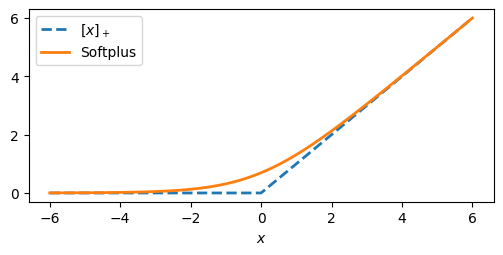

In [6]:
softplus_input = torch.linspace(-6.0, 6.0, 500)
softplus_values = F.softplus(softplus_input)
plus_values = torch.clamp(softplus_input, min=0.0)
plt.figure(figsize=(6, 2.5))
plt.plot(softplus_input, plus_values, "--", linewidth=2, label="$[x]_+$" )
plt.plot(softplus_input, softplus_values, linewidth=2, label="Softplus")
plt.xlabel("$x$")
plt.legend()
plt.show()

The softplus function is strictly increasing and its inverse is 
$$\operatorname{softplus}^{-1}(y) = y + \log(1 - e^{-y}).$$

This preserves useful gradients while guaranteeing physically admissible estimates. The initial guesses below deliberately differ from the true values.

In [7]:
def inverse_softplus(value):
    """Inverse of softplus"""
    value = torch.as_tensor(value, dtype=torch.get_default_dtype())
    return value + torch.log(-torch.expm1(-value))


class PositivePhysicalParameters(nn.Module):
    def __init__(self, m_initial=0.7, b_initial=2.0, k_initial=180.0):
        super().__init__()
        self.raw_m = nn.Parameter(inverse_softplus(m_initial))
        self.raw_b = nn.Parameter(inverse_softplus(b_initial))
        self.raw_k = nn.Parameter(inverse_softplus(k_initial))

    def forward(self):
        epsilon = 1e-8
        m = F.softplus(self.raw_m) + epsilon
        b = F.softplus(self.raw_b) + epsilon
        k = F.softplus(self.raw_k) + epsilon
        return m, b, k

## Physics-informed loss

Given a system response $\hat{y}(t; \theta)$, we define the *physics residual* at time $t$ as 
$$r(t)=m\ddot{\hat y}(t)+b\dot{\hat y}(t)+k\hat y(t)-F(t).$$

The training objective combines the (scaled) physics residual evaluated at time $(t_i)_i$ and a (scaled) observation loss evaluated at time $(t_j)_j$:

$$
\mathcal{L}(\theta)
=
\underbrace{\frac{1}{N}\sum_{i=1}^{N}\left(\frac{r(t_i)}{s_F}\right)^2}_{\text{scaled physics loss}}
+
\lambda_{\rm data}
\underbrace{\frac{1}{M}\sum_{j=1}^{M}
\left(\frac{\hat y(t_j)-y_j}{s_y}\right)^2}_{\text{scaled observation loss}}.
$$

The scaling factors $s_F$ and $s_y$ are the RMS force and standard deviation of the training response, respectively. Scaling both terms makes the loss balance easier to interpret. The validation observations do not appear in this objective.

In [8]:
def trajectory_and_derivatives(model, t):
    y = model(t)
    dydt = torch.autograd.grad(
        y, t, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]
    d2ydt2 = torch.autograd.grad(
        dydt, t, grad_outputs=torch.ones_like(dydt), create_graph=True
    )[0]
    return y, dydt, d2ydt2


def pinn_loss(
    model,
    physical_parameters,
    t_physics,
    t_data,
    y_data,
    force_scale,
    response_scale,
    lambda_data,
):
    y_physics, dydt, d2ydt2 = trajectory_and_derivatives(model, t_physics)
    m, b, k = physical_parameters()

    residual = (
        m * d2ydt2
        + b * dydt
        + k * y_physics
        - forcing(t_physics)
    )
    loss_physics = torch.mean((residual / force_scale).square())
    extra_initial_loss = residual[0].square() 

    y_predicted = model(t_data)
    loss_data = torch.mean(((y_predicted - y_data) / response_scale).square())

    total_loss = loss_physics + lambda_data * loss_data + 0.1 * extra_initial_loss
    return total_loss, loss_physics, loss_data

## PINN training

The network weights and the three physical parameters are optimised simultaneously. Separate learning rates are used because these groups of variables have different numerical scales. Adam first explores with relatively large steps; one learning-rate reduction then lets the estimates settle before the following full-batch L-BFGS refinement.

The physics grid combines uniform coverage of the full experiment with quadratically spaced points over the first $0.25$ seconds. This gives the optimiser additional information where the initial-acceleration residual is most difficult to learn. After Adam, L-BFGS performs a short full-batch refinement on this denser grid.

In [9]:
torch.manual_seed(7)

pinn = DisplacementPINN([32, 32, 32], t_final, y0, v0)
physical_parameters = PositivePhysicalParameters()

# Combine full-interval coverage with extra resolution near t = 0.
n_uniform_collocation = 600
n_initial_collocation = 100
initial_collocation_window = 0.25

t_uniform = torch.linspace(0.0, t_final, n_uniform_collocation)
t_initial = initial_collocation_window * torch.linspace(
    0.0, 1.0, n_initial_collocation
).square()
t_physics = torch.unique(
    torch.cat((t_uniform, t_initial)), sorted=True
).view(-1, 1).requires_grad_(True)
force_scale = torch.sqrt(torch.mean(forcing(t_physics.detach()).square()))
response_scale = y_train.std()
lambda_data = 1.1

print(f"Physics collocation points: {t_physics.shape[0]}")

n_epochs = 80000
log_every = 100

optimiser = torch.optim.Adam([
    {"params": pinn.parameters(), "lr": 2e-3},
    {"params": physical_parameters.parameters(), "lr": 2e-2},
])
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimiser, milestones=[20000, 50000], gamma=0.2
)

history = {
    name: [] for name in
    ("epoch", "total", "physics", "data", "m", "b", "k")
}

pinn.train()
progress = tqdm(range(n_epochs), desc="Training inverse PINN")

for epoch in progress:
    optimiser.zero_grad(set_to_none=True)
    t_physics.grad = None

    loss, loss_physics, loss_data = pinn_loss(
        pinn,
        physical_parameters,
        t_physics,
        t_train,
        y_train,
        force_scale,
        response_scale,
        lambda_data,
    )

    loss.backward()
    optimiser.step()
    scheduler.step()

    if epoch % log_every == 0 or epoch == n_epochs - 1:
        m_est, b_est, k_est = physical_parameters()

        history["epoch"].append(epoch)
        history["total"].append(loss.item())
        history["physics"].append(loss_physics.item())
        history["data"].append((lambda_data * loss_data).item())
        history["m"].append(m_est.item())
        history["b"].append(b_est.item())
        history["k"].append(k_est.item())

    if epoch % 1000 == 0:
        progress.set_postfix(loss=f"{loss.item():.3e}")

Physics collocation points: 699


Training inverse PINN:   0%|          | 0/80000 [00:00<?, ?it/s]

### L-BFGS refinement

Adam first brings the trajectory and physical parameters into a useful region of the loss landscape. We then jointly refine the network weights and the raw physical parameters with full-batch L-BFGS. PyTorch's L-BFGS optimiser requires a closure: a function that clears the gradients, recomputes the complete loss, and calls backward. The strong-Wolfe line search chooses a suitable step length.

In [10]:
lbfgs_history = {
    name: [] for name in
    ("evaluation", "total", "physics", "data", "m", "b", "k")
}

lbfgs = torch.optim.LBFGS(
    list(pinn.parameters()) + list(physical_parameters.parameters()),
    lr=2.,
    history_size=80,
    max_iter=250,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    line_search_fn="strong_wolfe",
)

def closure():
    lbfgs.zero_grad(set_to_none=True)
    t_physics.grad = None
    loss, loss_physics, loss_data = pinn_loss(
        pinn,
        physical_parameters,
        t_physics,
        t_train,
        y_train,
        force_scale,
        response_scale,
        lambda_data,
    )
    loss.backward()

    lbfgs_history["evaluation"].append(len(lbfgs_history["evaluation"]))
    lbfgs_history["total"].append(loss.item())
    lbfgs_history["physics"].append(loss_physics.item())
    lbfgs_history["data"].append((lambda_data * loss_data).item())
    m_est, b_est, k_est = physical_parameters()
    lbfgs_history["m"].append(m_est.item())
    lbfgs_history["b"].append(b_est.item())
    lbfgs_history["k"].append(k_est.item())
    return loss

lbfgs.step(closure)
loss, loss_physics, loss_data = pinn_loss(
    pinn,
    physical_parameters,
    t_physics,
    t_train,
    y_train,
    force_scale,
    response_scale,
    lambda_data,
)
# Append the final accepted L-BFGS state after the line search finishes.
lbfgs_history["evaluation"].append(len(lbfgs_history["evaluation"]))
lbfgs_history["total"].append(loss.item())
lbfgs_history["physics"].append(loss_physics.item())
lbfgs_history["data"].append((lambda_data * loss_data).item())
m_est, b_est, k_est = physical_parameters()
lbfgs_history["m"].append(m_est.item())
lbfgs_history["b"].append(b_est.item())
lbfgs_history["k"].append(k_est.item())
print(f"Loss after L-BFGS: {loss.item():.3e}")
print(f"Physics loss after L-BFGS: {loss_physics.item():.3e}")

Loss after L-BFGS: 6.976e-04
Physics loss after L-BFGS: 1.561e-04


## Validation of the learned trajectory

The dense reference trajectory is used only for validation in this synthetic example. We report:

- RMSE against the reference trajectory over the full interval,
- RMSE at the held-out noisy observations, and
- relative errors in the three physical parameters.

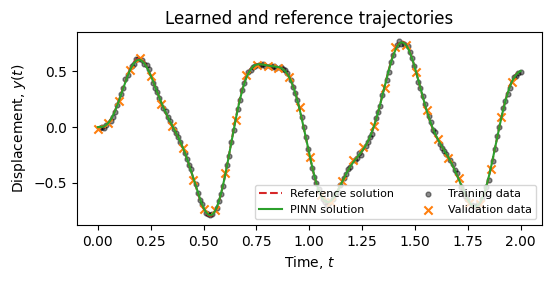

Full-trajectory RMSE: 0.0041
Validation-data RMSE: 0.0123

m estimate:    1.029  (true: 1, relative error: 2.90%)
b estimate:    4.039  (true: 4, relative error: 0.98%)
k estimate:  254.318  (true: 250, relative error: 1.73%)


In [11]:
pinn.eval()

with torch.no_grad():
    y_pinn = pinn(t_test)
    y_validation_predicted = pinn(t_validation)

trajectory_rmse = torch.sqrt(torch.mean((y_pinn - y_exact).square()))
validation_rmse = torch.sqrt(
    torch.mean((y_validation_predicted - y_validation).square())
)

m_est, b_est, k_est = physical_parameters()
parameter_estimates = {
    "m": (m_est.item(), m_true),
    "b": (b_est.item(), b_true),
    "k": (k_est.item(), k_true),
}

plt.figure(figsize=(6, 2.5))
plt.plot(
    t_test[:, 0], y_exact[:, 0], "--",
    color="tab:red", label="Reference solution"
)
plt.plot(
    t_test[:, 0], y_pinn[:, 0],
    color="tab:green", label="PINN solution"
)
plt.scatter(
    t_train[:, 0], y_train[:, 0], s=12,
    color="black", alpha=0.45, label="Training data"
)
plt.scatter(
    t_validation[:, 0], y_validation[:, 0], marker="x", s=35,
    color="tab:orange", label="Validation data"
)
plt.xlabel("Time, $t$")
plt.ylabel("Displacement, $y(t)$")
plt.title("Learned and reference trajectories")
plt.legend(ncol=2, fontsize=8, loc='lower right')
plt.show()

print(f"Full-trajectory RMSE: {trajectory_rmse.item():.4f}")
print(f"Validation-data RMSE: {validation_rmse.item():.4f}")
print()
for name, (estimate, truth) in parameter_estimates.items():
    relative_error = abs(estimate - truth) / truth
    print(
        f"{name} estimate: {estimate:8.3f}  "
        f"(true: {truth:g}, relative error: {relative_error:.2%})"
    )

### Convergence diagnostics

A close trajectory fit is not enough: an inverse PINN should also show that its parameter estimates and both parts of the objective have stabilised. Adam progress is indexed by epoch. L-BFGS progress is indexed by closure evaluation because its line search may evaluate several trial steps during one optimiser iteration; its curves therefore need not decrease monotonically. The two phases are placed consecutively on one axis, and a dashed line marks the solver change.

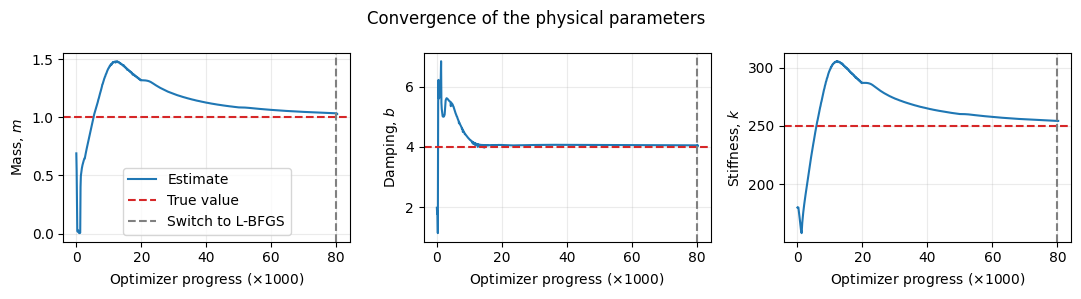

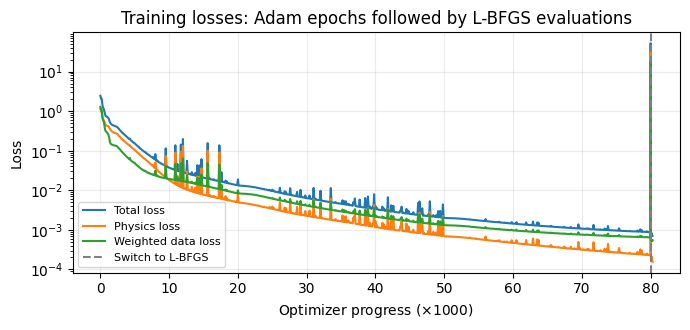

In [12]:
solver_switch = n_epochs
adam_progress = np.asarray(history["epoch"])
lbfgs_progress = solver_switch + np.asarray(lbfgs_history["evaluation"])
optimizer_progress = np.concatenate((adam_progress, lbfgs_progress))
progress_in_thousands = optimizer_progress / 1000
switch_in_thousands = solver_switch / 1000

fig, axes = plt.subplots(1, 3, figsize=(11, 3))

parameter_results = [
    ("m", m_true, "Mass, $m$"),
    ("b", b_true, "Damping, $b$"),
    ("k", k_true, "Stiffness, $k$"),
]

for axis, (name, true_value, label) in zip(axes, parameter_results):
    parameter_history = np.concatenate((history[name], lbfgs_history[name]))
    axis.plot(progress_in_thousands, parameter_history, label="Estimate")
    axis.axhline(
        true_value, linestyle="--", color="tab:red", label="True value"
    )
    axis.axvline(
        switch_in_thousands, linestyle="--", color="gray",
        label="Switch to L-BFGS",
    )
    axis.set_xlabel(r"Optimizer progress ($\times 1000$)")
    axis.set_ylabel(label)
    axis.grid(alpha=0.25)

axes[0].legend()
fig.suptitle("Convergence of the physical parameters")
fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.4))
for name, label in (
    ("total", "Total loss"),
    ("physics", "Physics loss"),
    ("data", "Weighted data loss"),
):
    combined_loss = np.concatenate((history[name], lbfgs_history[name]))
    plt.semilogy(progress_in_thousands, combined_loss, label=label)

plt.axvline(
    switch_in_thousands, linestyle="--", color="gray",
    label="Switch to L-BFGS",
)
plt.xlabel(r"Optimizer progress ($\times 1000$)")
plt.ylabel("Loss")
plt.title("Training losses: Adam epochs followed by L-BFGS evaluations")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Physics-residual validation

Calling `pinn.eval()` changes the behaviour of layers such as dropout, but it does not disable automatic differentiation. We therefore keep gradients enabled while evaluating the ODE residual on a finer grid than the one used for training.

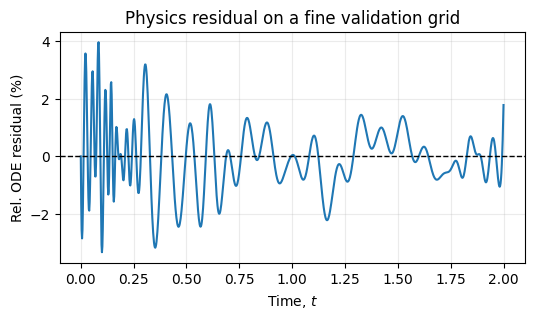

Residual RMS: 0.866
Residual RMS relative: 1.13%


In [13]:
t_residual = torch.linspace(
    0.0, t_final, 1000
).view(-1, 1).requires_grad_(True)

y_residual, dydt_residual, d2ydt2_residual = trajectory_and_derivatives(
    pinn, t_residual
)
m_est, b_est, k_est = physical_parameters()

residual = (
    m_est * d2ydt2_residual
    + b_est * dydt_residual
    + k_est * y_residual
    - forcing(t_residual)
).detach()

residual_rms = torch.sqrt(torch.mean(residual.square()))
relative_residual_rms = residual_rms / force_scale

plt.figure(figsize=(6, 3))
plt.plot(t_residual.detach()[:, 0], 100 * residual[:, 0] / force_scale)
plt.axhline(0.0, linestyle="--", color="black", linewidth=1)
plt.xlabel("Time, $t$")
plt.ylabel("Rel. ODE residual (%)")
plt.title("Physics residual on a fine validation grid")
plt.grid(alpha=0.25)
plt.show()

print(f"Residual RMS: {residual_rms.item():.3f}")
print(f"Residual RMS relative: {relative_residual_rms.item():.2%}")

## Exercises

1. Replace the multi-sine force by a single sine wave. How does this affect convergence and parameter accuracy?
2. Vary the number of observations and the noise standard deviation. Which parameter is most sensitive?
3. Change the initial guesses in `PositivePhysicalParameters`. Do the estimates converge to the same solution?
4. Treat $y_0$ and $v_0$ as unknown parameters and estimate them jointly with $(m,b,k)$.

## Sensitivity analysis

**Identifiability:** There are models where it is impossible to identify the parameter vector from data. For example, if we have $m\ddot{y} + b\dot{y} + ky = 0$, then the triples $\theta = (m, k, b)$ and $\theta' = (2m, 2k, 2b)$ both satisfy the ODE. This raises the question of identifiability. 

**Weak identifiability:** There can be cases where two distinct parameter vectors $\theta \neq \theta'$ generate almost indistinguishable responses. It makes sense to look at the sensitivity of the output $y(t; \theta)$, at a given $t$, on the parameters $\theta$. For example, suppose we have estimated the parameter vector $\hat{\theta}$. If 
$$\left. \frac{\partial y(t)}{\partial \theta_i} \right|_{\theta = \hat\theta} \approx 0,$$
for all $t$, parameter $\theta_i$ can hardly be identified from data. Put simply, this would imply that any parameter around $\hat\theta$ produces almost identical responses.

**Sensitivity.** Given a set of time instants $t_j$ we define the local sensitivity matrix
$$S_{ji}=\left.\frac{\partial [y(t_j)/s_y]}{\partial\log\theta_i}\right|_{\theta = \hat\theta}
=\frac{\theta_i}{s_y} \left.\frac{\partial y(t_j)}{\partial\theta_i}\right|_{\theta = \hat\theta}.$$

The logarithmic parameterization makes the columns dimensionless and compares equal *relative* changes in parameters. Let us first compute the matrix $S = (S_{ji})_{ji}$.

🧐 **Implementation note:** Here we're being lazy and use central differences to estimate the derivative in $S_{ji}$. In principle, we can use automatic differentiation, but we have to do a few changes in the code above, e.g., use `requires_grad_(True)` in the definition of all parameters.

In [ ]:
parameter_names = ("m", "b", "k")
with torch.no_grad():
    fitted_parameters = torch.stack(physical_parameters()).detach()

relative_step = 1e-3
sensitivity_columns = []

for parameter_index in range(len(parameter_names)):
    step = relative_step * fitted_parameters[parameter_index].abs()
    parameters_plus = fitted_parameters.clone()
    parameters_minus = fitted_parameters.clone()
    parameters_plus[parameter_index] += step
    parameters_minus[parameter_index] -= step
    # Approximate derivative with central diffs
    y_plus = simulate_oscillator( t_test[:, 0], *parameters_plus, y0, v0 )[:, 0]
    y_minus = simulate_oscillator( t_test[:, 0], *parameters_minus, y0, v0 )[:, 0]
    derivative = (y_plus - y_minus) / (2.0 * step)
    sensitivity_columns.append(derivative)

sensitivity_full = torch.stack(sensitivity_columns, dim=1)
training_indices = observation_indices[training_mask]
sensitivity = sensitivity_full[training_indices]
sensitivity_times = t_test[training_indices, 0]

# Sensitivity to log-parameters, normalized by the response scale
normalized_sensitivity = (
    sensitivity * fitted_parameters.view(1, -1) / response_scale
)


Further explanations go here...

In [442]:
_, singular_values, right_singular_vectors = torch.linalg.svd(
    normalized_sensitivity, full_matrices=False
)
condition_number = singular_values[0] / singular_values[-1]

column_norms = torch.linalg.vector_norm(normalized_sensitivity, dim=0)
cosine_similarity = (
    normalized_sensitivity.T @ normalized_sensitivity
) / torch.outer(column_norms, column_norms)

weak_direction = right_singular_vectors[-1]
weak_direction = weak_direction / torch.max(torch.abs(weak_direction))

print("Singular values:", singular_values.cpu().numpy())
print(f"Sensitivity condition number: {condition_number.item():.1f}")

print(f"The weakest direction is {weak_direction[0]: .2f} δ(log{parameter_names[0]}) {weak_direction[1] :+.2f} δ(log{parameter_names[1]}) {weak_direction[2] :+.2f} δ(log{parameter_names[2]})")


Singular values: [22.390654   3.97854    3.3718617]
Sensitivity condition number: 6.6
The weakest direction is  0.55 δ(logm) -1.00 δ(logb) +0.27 δ(logk)


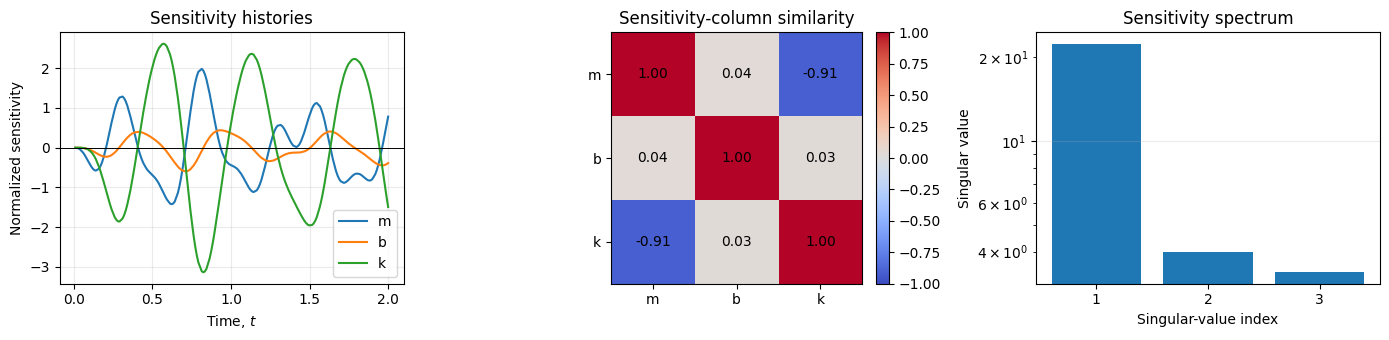

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for column, name in enumerate(parameter_names):
    axes[0].plot(
        sensitivity_times.cpu(),
        normalized_sensitivity[:, column].cpu(),
        label=name,
    )
axes[0].axhline(0.0, color="black", linewidth=0.7)
axes[0].set(
    xlabel="Time, $t$", ylabel="Normalized sensitivity",
    title="Sensitivity histories",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

image = axes[1].imshow(
    cosine_similarity.cpu(), vmin=-1.0, vmax=1.0, cmap="coolwarm"
)
axes[1].set_xticks(range(3), parameter_names)
axes[1].set_yticks(range(3), parameter_names)
axes[1].set_title("Sensitivity-column similarity")
for row in range(3):
    for column in range(3):
        axes[1].text(
            column, row, f"{cosine_similarity[row, column].item():.2f}",
            ha="center", va="center",
        )
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].bar(range(1, 4), singular_values.cpu())
axes[2].set_yscale("log")
axes[2].set_xticks(range(1, 4))
axes[2].set(
    xlabel="Singular-value index", ylabel="Singular value",
    title="Sensitivity spectrum",
)
axes[2].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()